In [46]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, accuracy_score, precision_score, f1_score, roc_auc_score, ConfusionMatrixDisplay, classification_report


In [47]:
df = pd.read_csv("../data/heart_cleaned.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,country,clinical_index
0,28.0,1.0,2.0,130.0,132.0,0.0,2.0,185.0,0.0,0.0,NaN,NaN,NaN,0,Hungary,-3.920000
1,29.0,1.0,2.0,120.0,243.0,0.0,0.0,160.0,0.0,0.0,NaN,NaN,NaN,1,Hungary,-0.670000
2,29.0,1.0,2.0,140.0,241.0,0.0,0.0,170.0,0.0,0.0,NaN,NaN,NaN,0,Hungary,-1.947393
3,30.0,0.0,1.0,170.0,237.0,0.0,1.0,170.0,0.0,0.0,NaN,NaN,6.0,0,Hungary,-1.160000
4,31.0,0.0,2.0,100.0,219.0,0.0,1.0,150.0,0.0,0.0,NaN,NaN,NaN,0,Hungary,-0.690000


In [48]:
df.shape

(918, 16)

In [49]:
df.isna().sum().sort_values(ascending=False)

ca                609
thal              484
slope             308
age                 0
chol                0
sex                 0
cp                  0
trestbps            0
thalach             0
restecg             0
fbs                 0
oldpeak             0
exang               0
target              0
country             0
clinical_index      0
dtype: int64

Baseline model without high-missing variables.
Model A

In [50]:
df_model = df.drop(columns=["thal", "slope", "ca"])

In [51]:
X = df_model.drop(columns=["target"])
y = df_model["target"]

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [53]:
categorial_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "country"
]

numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "clinical_index"
]

In [54]:
preprocessor = ColumnTransformer(
    transformers = [
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(drop="first"), categorial_features)
    ]
)

In [55]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [56]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [57]:
y_pred = model.predict(X_test)

## Model Predictions

After training the baseline Logistic Regression model, predictions were generated on the test dataset. These predictions will be used to evaluate model performance.

In [58]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy score: ", accuracy)

Accuracy score:  0.7554347826086957


Accuracy

Accuracy measures the proportion of correct predictions among all test observations.

It is calculated as:

correct predictions / all predictions

Accuracy is useful as a first overview, but it can be misleading if the classes are imbalanced.

In [59]:
precision = precision_score(y_test, y_pred)
print("Precision score: ", precision)

Precision score:  0.7894736842105263



Precision measures how many patients predicted as having heart disease actually have heart disease.

A high precision means that when the model predicts heart disease, it is usually correct.

 Precision

The baseline model achieved a precision score of 0.78.

This means that approximately 78% of patients predicted as having heart disease were correctly classified. The model produces relatively few false positive predictions.

In [60]:
recall = recall_score(y_test, y_pred)
print("Recall score: ", recall)

Recall score:  0.75


Recall

The baseline model achieved a recall score of 0.75.

This indicates that approximately 75% of patients with heart disease were correctly identified by the model. In other words, the model missed around 25% of actual heart disease cases.

Since heart disease detection is a medical classification task, recall is an important metric because false negatives may have serious consequences.

In [61]:
f1 = f1_score(y_test, y_pred)
print("F1 score: ", f1)

F1 score:  0.7692307692307693


F1 Score

The baseline model achieved an F1 score of 0.77.

The F1 score combines precision and recall into a single metric and is particularly useful when evaluating classification models in healthcare settings.

The relatively balanced precision (0.78) and recall (0.75) resulted in a strong overall F1 score, indicating a balanced classification performance.

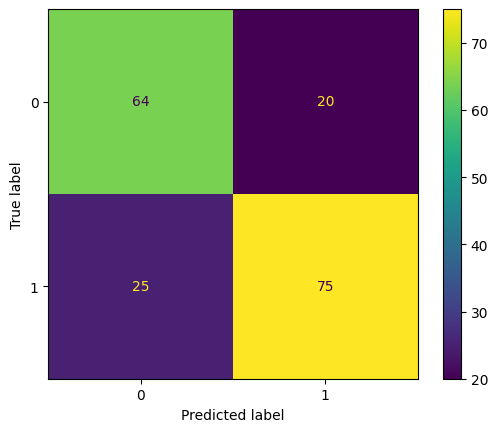

In [62]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

## Confusion Matrix Interpretation

The baseline model correctly identified:

- 64 healthy patients (True Negatives)
- 75 patients with heart disease (True Positives)

The model incorrectly classified:

- 20 healthy patients as having heart disease (False Positives)
- 25 heart disease patients as healthy (False Negatives)

The confusion matrix shows that the model is reasonably balanced, with similar numbers of false positives and false negatives. However, the 25 missed heart disease cases suggest that there is still room for improvement, particularly in recall.

In [68]:
y_prob = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC score: ", roc_auc)

ROC-AUC score:  0.8341666666666666


## ROC-AUC Score

The baseline Logistic Regression model achieved a ROC-AUC score of 0.83.

This indicates good discriminative performance. In practical terms, the model has approximately an 83% probability of assigning a higher risk score to a patient with heart disease than to a healthy patient.

Among all evaluation metrics, ROC-AUC provides one of the most informative assessments of overall classification performance because it evaluates the quality of probability rankings rather than a single classification threshold.

# Model B: Including Slope

In this experiment, the `slope` variable is retained to evaluate whether the additional information improves predictive performance compared to the baseline model.